In [1]:
# ============================================================
# CELL 1 — Install and Import
# ============================================================
!pip install wfdb neurokit2 -q

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks, butter, filtfilt, welch
from scipy.interpolate import interp1d
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
# ============================================================
# CELL 2 — Helper Functions
# ============================================================

def bandpass_filter(signal, lowcut=0.5, highcut=2.0, fs=125, order=3):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

def hrv_frequency_features(ibi):
    try:
        fs = 4.0
        t = np.cumsum(ibi) / 1000.0
        if t[-1] - t[0] < 10:
            return {"lf_power": np.nan, "hf_power": np.nan, "lf_hf_ratio": np.nan}
        f = interp1d(t, ibi, kind='linear', fill_value='extrapolate')
        t_resampled = np.arange(t[0], t[-1], 1 / fs)
        ibi_resampled = f(t_resampled)
        freqs, psd = welch(ibi_resampled, fs=fs, nperseg=min(64, len(ibi_resampled)))
        lf_mask = (freqs >= 0.04) & (freqs < 0.15)
        hf_mask = (freqs >= 0.15) & (freqs < 0.40)
        lf = np.trapz(psd[lf_mask], freqs[lf_mask])
        hf = np.trapz(psd[hf_mask], freqs[hf_mask])
        return {"lf_power": lf, "hf_power": hf, "lf_hf_ratio": lf / (hf + 1e-9)}
    except Exception:
        return {"lf_power": np.nan, "hf_power": np.nan, "lf_hf_ratio": np.nan}

def extract_ppg_features(segment, sampling_rate=125):
    try:
        filtered = bandpass_filter(segment, fs=sampling_rate)
        peaks, _ = find_peaks(
            filtered,
            distance=int(0.45 * sampling_rate),
            height=np.percentile(filtered, 50)
        )
        if len(peaks) < 3:
            return None
        ibi = np.diff(peaks) / sampling_rate * 1000
        ibi = ibi[(ibi >= 300) & (ibi <= 2000)]
        if len(ibi) < 3:
            return None
        diff_ibi = np.diff(ibi)
        features = {
            "mean_ibi":     np.mean(ibi),
            "std_ibi":      np.std(ibi),
            "rmssd":        np.sqrt(np.mean(diff_ibi ** 2)),
            "pnn50":        np.sum(np.abs(diff_ibi) > 50) / max(len(diff_ibi), 1),
            "cv_ibi":       np.std(ibi) / (np.mean(ibi) + 1e-9),
            "mean_hr":      60000 / (np.mean(ibi) + 1e-9),
            "std_hr":       np.std(60000 / (ibi + 1e-9)),
            "min_hr":       60000 / (np.max(ibi) + 1e-9),
            "max_hr":       60000 / (np.min(ibi) + 1e-9),
            "mean_amp":     np.mean(segment[peaks]),
            "std_amp":      np.std(segment[peaks]),
            "skewness":     pd.Series(segment).skew(),
            "kurtosis":     pd.Series(segment).kurt(),
            "signal_range": np.ptp(segment),
        }
        freq_feats = hrv_frequency_features(ibi)
        features.update(freq_feats)
        return features
    except Exception:
        return None

def clean_sig_names(record):
    return [s.strip(',').strip() for s in record.sig_name]

def get_ppg(record):
    names = clean_sig_names(record)
    if 'PLETH' in names:
        return record.p_signal[:, names.index('PLETH')]
    print(f"  Warning: PLETH not found. Signals: {record.sig_name}")
    return None

def get_window_label(num_record, sec_start, sec_end):
    try:
        names = clean_sig_names(num_record)
        if 'HR' not in names:
            return None
        hr_idx    = names.index('HR')
        hr_values = num_record.p_signal[sec_start:sec_end, hr_idx]
        hr_values = hr_values[~np.isnan(hr_values)]
        if len(hr_values) == 0:
            return None
        mean_hr = np.mean(hr_values)
        if mean_hr < 60:
            return 'bradycardia'
        elif mean_hr > 100:
            return 'tachycardia'
        else:
            return 'normal'
    except Exception:
        return None

print("✅ Helper functions defined")

✅ Helper functions defined


In [3]:
# ============================================================
# CELL 3 — Build Dataset from all 53 BIDMC records
# ============================================================

sampling_rate = 125
window_size   = 30 * sampling_rate
step_size     = 30 * sampling_rate
record_ids    = [f'bidmc{str(i).zfill(2)}' for i in range(1, 54)]

all_features = []
all_labels   = []

for record_id in record_ids:
    try:
        record     = wfdb.rdrecord(record_id,       pn_dir='bidmc')
        num_record = wfdb.rdrecord(record_id + 'n', pn_dir='bidmc')

        ppg = get_ppg(record)
        if ppg is None:
            continue

        for start in range(0, len(ppg) - window_size, step_size):
            end       = start + window_size
            sec_start = start // sampling_rate
            sec_end   = end   // sampling_rate

            label = get_window_label(num_record, sec_start, sec_end)
            if label is None:
                continue

            feats = extract_ppg_features(ppg[start:end], sampling_rate)
            if feats is not None:
                all_features.append(feats)
                all_labels.append(label)

    except Exception as e:
        print(f"Skipping {record_id}: {e}")

df = pd.DataFrame(all_features).dropna()
df['label'] = all_labels[:len(df)]

print(f"✅ Total windows: {len(df)}")
print(df['label'].value_counts())

# Save immediately — never rerun this cell
df.to_csv('bidmc_features.csv', index=False)
print("✅ Saved to bidmc_features.csv")

/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])


✅ Total windows: 848
label
normal         704
tachycardia    139
bradycardia      5
Name: count, dtype: int64
✅ Saved to bidmc_features.csv


In [4]:
# ============================================================
# CELL 4 — Load, Clean and Preprocess
# (If already saved, start here: df = pd.read_csv('bidmc_features.csv'))
# ============================================================

df = pd.read_csv('bidmc_features.csv')
df = df.reset_index(drop=True)

# Step 1: Separate label before any cleaning
labels_backup = df['label'].copy()
feature_cols  = [c for c in df.columns if c != 'label']

# Step 2: Remove inf/nan
features_df = df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()

# Step 3: Remove outlier windows (beyond 3 std)
z_scores = np.abs((features_df - features_df.mean()) / features_df.std())
mask      = (z_scores < 3).all(axis=1)
clean_idx = features_df[mask].index

# Step 4: Rebuild df with aligned labels
df = df.loc[clean_idx].reset_index(drop=True)

print(f"✅ After outlier removal: {len(df)} windows")
print(df['label'].value_counts())

✅ After outlier removal: 752 windows
label
normal         646
tachycardia    105
bradycardia      1
Name: count, dtype: int64


In [5]:
df.head()

,mean_ibi,std_ibi,rmssd,pnn50,cv_ibi,mean_hr,std_hr,min_hr,max_hr,mean_amp,std_amp,skewness,kurtosis,signal_range,lf_power,hf_power,lf_hf_ratio,label
0,638.956522,14.214133,23.308558,0.044444,0.022246,93.903103,2.122593,88.235294,102.739726,0.581082,0.019910,0.733819,-0.741872,0.266861,2.068230,13.907024,0.148718,normal
1,672.558140,95.477576,134.891844,0.047619,0.141962,89.211618,6.863824,46.583851,93.750000,0.577357,0.021824,0.770405,-0.563505,0.304986,2625.006180,4763.775188,0.551035,normal
2,659.090909,10.949924,17.166761,0.023256,0.016614,91.034483,1.509342,86.206897,94.936709,0.576692,0.012924,0.666999,-0.816098,0.247313,2.216579,26.874158,0.082480,normal
3,658.488889,15.162266,23.386088,0.045455,0.023026,91.117711,2.139814,87.209302,98.684211,0.569255,0.019037,0.741161,-0.618198,0.249267,7.782121,32.946603,0.236204,normal
4,656.181818,8.088355,12.501163,0.000000,0.012326,91.438071,1.137793,89.285714,94.936709,0.576974,0.016514,0.776982,-0.661693,0.272728,1.236635,2.090546,0.591537,normal


In [6]:
df.tail()

,mean_ibi,std_ibi,rmssd,pnn50,cv_ibi,mean_hr,std_hr,min_hr,max_hr,mean_amp,std_amp,skewness,kurtosis,signal_range,lf_power,hf_power,lf_hf_ratio,label
747,705.951220,133.932992,172.148773,0.625000,0.189720,84.991708,14.474309,57.251908,119.047619,2.682655,0.312645,0.488062,-0.664625,2.773245,1770.614968,2831.755129,0.625271,normal
748,655.466667,90.594481,132.121157,0.522727,0.138214,91.537836,12.449304,58.139535,131.578947,2.654026,0.311582,0.411853,-0.916705,2.630514,532.552709,1759.753383,0.302629,normal
749,708.878049,151.200754,229.249209,0.775000,0.213296,84.640793,16.099043,51.020408,122.950820,2.644465,0.322930,0.456291,-0.667595,2.844610,1748.325603,6203.536560,0.281827,normal
750,722.000000,146.846859,170.818842,0.615385,0.203389,83.102493,14.752416,55.147059,125.000000,2.645160,0.327796,0.512194,-0.705383,2.705768,4744.132479,6340.406472,0.748238,normal
751,706.926829,140.463413,178.867549,0.675000,0.198696,84.874413,16.196574,54.347826,129.310345,2.619652,0.314067,0.593942,-0.575456,2.639302,3138.383214,3736.596040,0.839904,normal


In [7]:
df.describe()

,mean_ibi,std_ibi,rmssd,pnn50,cv_ibi,mean_hr,std_hr,min_hr,max_hr,mean_amp,std_amp,skewness,kurtosis,signal_range,lf_power,hf_power,lf_hf_ratio
count,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000
mean,696.710245,49.427862,70.195038,0.170635,0.070911,87.665328,5.368169,73.482009,101.138282,0.889988,0.063689,0.487536,-0.626487,0.755402,575.105983,1223.741399,0.722406
std,93.171175,52.795685,75.154060,0.225429,0.075379,11.816514,5.330280,16.931508,17.216375,0.661900,0.052323,0.294023,0.511608,0.583727,1499.835354,2596.580618,1.074697
min,484.266667,4.225907,4.618802,0.000000,0.005398,59.659091,0.414004,34.090909,63.559322,0.532536,0.006191,-0.451217,-1.400408,0.155428,0.048569,0.891303,0.004935
25%,652.545455,11.151881,15.264698,0.000000,0.016705,80.764297,1.477195,60.483871,88.235294,0.609156,0.028318,0.295359,-0.994437,0.434021,3.624812,11.772523,0.152288
50%,685.269103,20.915473,31.053923,0.063830,0.031343,87.556847,2.768348,76.530612,98.043404,0.666444,0.050541,0.457732,-0.701584,0.585523,15.998843,44.801993,0.356589
75%,742.902632,87.657990,119.046245,0.266667,0.127280,91.947618,7.856301,86.206897,113.636364,0.697392,0.081292,0.678084,-0.398663,0.754640,194.922796,614.545112,0.768242
max,1005.714286,226.931451,329.465415,0.902439,0.329268,123.898678,24.078821,119.047619,133.928571,2.921557,0.329855,1.214800,2.172751,3.304999,14165.174688,15670.982668,7.825826


In [10]:
df['label'].value_counts()


,count
label,
normal,646
tachycardia,105
bradycardia,1


In [11]:
# ============================================================
# CELL 5 — Drop Unreliable Features + Log Transform
# ============================================================

# Drop features that depend on accurate peak detection
# (unreliable due to dicrotic notch in PPG)
unreliable = ['rmssd', 'std_ibi', 'pnn50',
              'lf_power', 'hf_power', 'lf_hf_ratio',
              'min_hr', 'max_hr']
df = df.drop(columns=[c for c in unreliable if c in df.columns])

# Log transform skewed features
for col in ['std_hr', 'std_amp']:
    if col in df.columns:
        df[f'{col}_log'] = np.log1p(df[col])
        df = df.drop(columns=col)

feature_cols = [c for c in df.columns if c != 'label']
print("✅ Final features:", feature_cols)
print(f"Total features: {len(feature_cols)}")
print(df[feature_cols].describe().round(2))

✅ Final features: ['mean_ibi', 'cv_ibi', 'mean_hr', 'mean_amp', 'skewness', 'kurtosis', 'signal_range', 'std_hr_log', 'std_amp_log']
Total features: 9
       mean_ibi  cv_ibi  mean_hr  mean_amp  skewness  kurtosis  signal_range  \
count    752.00  752.00   752.00    752.00    752.00    752.00        752.00   
mean     696.71    0.07    87.67      0.89      0.49     -0.63          0.76   
std       93.17    0.08    11.82      0.66      0.29      0.51          0.58   
min      484.27    0.01    59.66      0.53     -0.45     -1.40          0.16   
25%      652.55    0.02    80.76      0.61      0.30     -0.99          0.43   
50%      685.27    0.03    87.56      0.67      0.46     -0.70          0.59   
75%      742.90    0.13    91.95      0.70      0.68     -0.40          0.75   
max     1005.71    0.33   123.90      2.92      1.21      2.17          3.30   

       std_hr_log  std_amp_log  
count      752.00       752.00  
mean         1.55         0.06  
std          0.76         0.0

In [12]:
df.head()

,mean_ibi,cv_ibi,mean_hr,mean_amp,skewness,kurtosis,signal_range,label,std_hr_log,std_amp_log
0,638.956522,0.022246,93.903103,0.581082,0.733819,-0.741872,0.266861,normal,1.138664,0.019714
1,672.558140,0.141962,89.211618,0.577357,0.770405,-0.563505,0.304986,normal,2.062273,0.021590
2,659.090909,0.016614,91.034483,0.576692,0.666999,-0.816098,0.247313,normal,0.920021,0.012841
3,658.488889,0.023026,91.117711,0.569255,0.741161,-0.618198,0.249267,normal,1.144163,0.018858
4,656.181818,0.012326,91.438071,0.576974,0.776982,-0.661693,0.272728,normal,0.759774,0.016379


In [13]:
# ============================================================
# CELL 6 — Isolation Forest
# ============================================================

X      = df[feature_cols]
y_true = (df['label'] != 'normal').astype(int)

print(f"Anomaly fraction: {y_true.mean():.2f}")

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train
iso = IsolationForest(
    n_estimators=200,
    contamination=round(y_true.mean(), 2),
    random_state=42
)
iso.fit(X_scaled)

# Predict
y_pred = (iso.predict(X_scaled) == -1).astype(int)
scores = iso.decision_function(X_scaled)

df['anomaly_score'] = scores
df['predicted']     = y_pred

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

Anomaly fraction: 0.14

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90       646
     Anomaly       0.42      0.42      0.42       106

    accuracy                           0.84       752
   macro avg       0.66      0.66      0.66       752
weighted avg       0.84      0.84      0.84       752



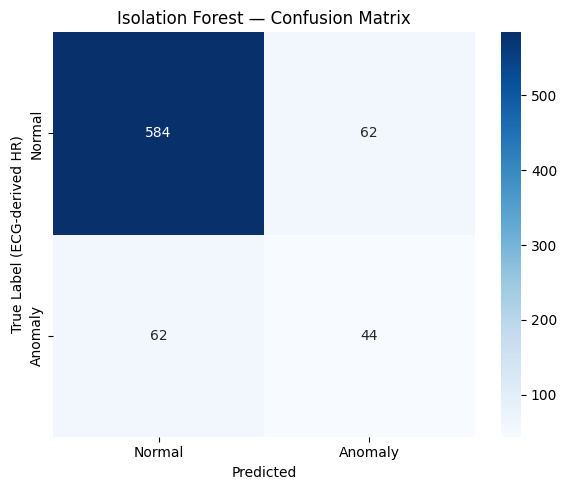

In [14]:
# ============================================================
# CELL 7 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cmap='Blues')
plt.title("Isolation Forest — Confusion Matrix")
plt.ylabel("True Label (ECG-derived HR)")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

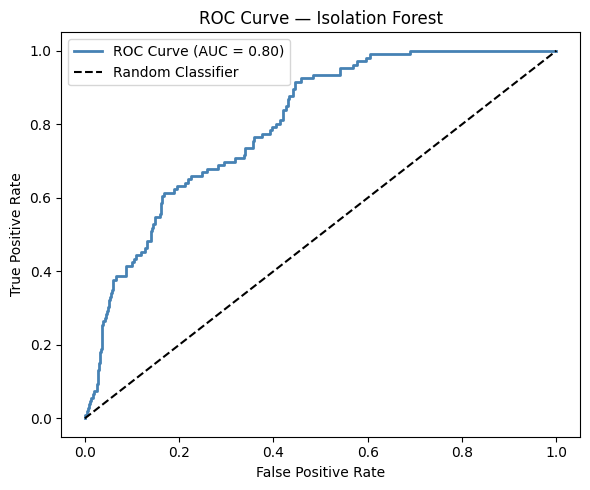

AUC Score: 0.802


In [15]:
# ============================================================
# CELL 8 — ROC Curve
# ============================================================

fpr, tpr, _ = roc_curve(y_true, -scores)
auc         = roc_auc_score(y_true, -scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Isolation Forest")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.3f}")

/tmp/ipykernel_2667/3311854850.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='label', y='anomaly_score',


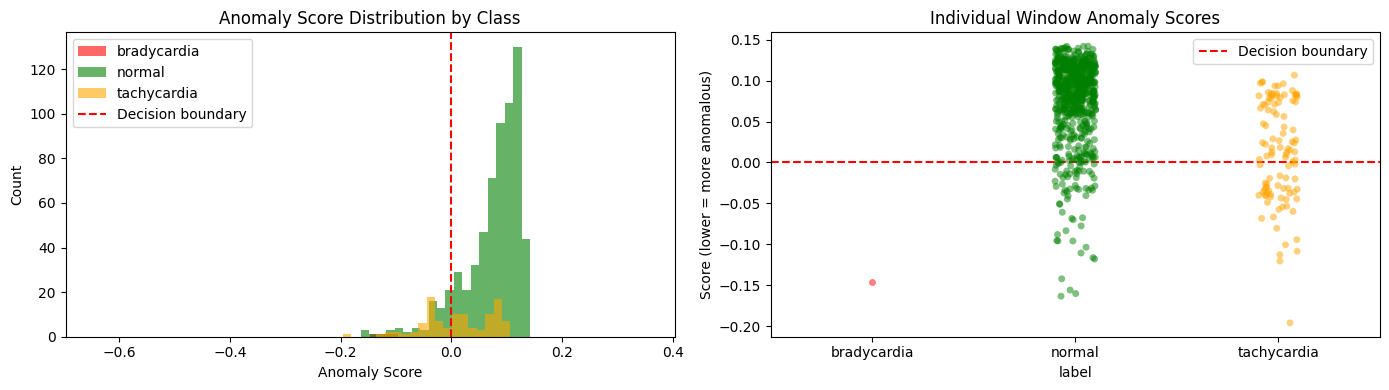

In [16]:
# ============================================================
# CELL 9 — Anomaly Score Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
for label, group in df.groupby('label'):
    color = 'green' if label == 'normal' else 'red' if label == 'bradycardia' else 'orange'
    axes[0].hist(group['anomaly_score'], bins=20, alpha=0.6,
                 label=label, color=color)
axes[0].axvline(0, color='red', linestyle='--', label='Decision boundary')
axes[0].set_title("Anomaly Score Distribution by Class")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Stripplot
sns.stripplot(data=df, x='label', y='anomaly_score',
              order=['bradycardia', 'normal', 'tachycardia'],
              palette={'normal': 'green',
                       'bradycardia': 'red',
                       'tachycardia': 'orange'},
              alpha=0.5, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', label='Decision boundary')
axes[1].set_title("Individual Window Anomaly Scores")
axes[1].set_ylabel("Score (lower = more anomalous)")
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2667/1110736977.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


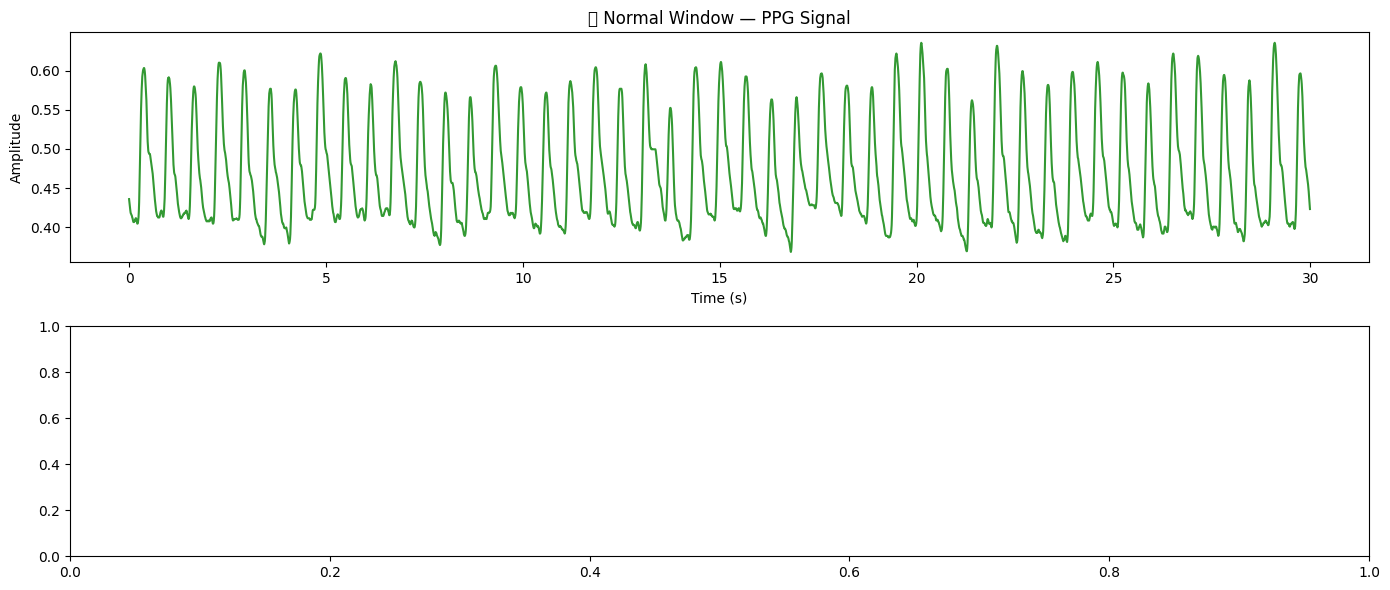

In [17]:
# ============================================================
# CELL 10 — Show Real PPG Signals (Normal vs Anomalous)
# ============================================================

record     = wfdb.rdrecord('bidmc01', pn_dir='bidmc')
num_record = wfdb.rdrecord('bidmc01n', pn_dir='bidmc')
ppg        = get_ppg(record)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
t = np.arange(window_size) / sampling_rate

# Normal window
segment_normal = ppg[0:window_size]
axes[0].plot(t, segment_normal, color='green', alpha=0.8)
axes[0].set_title("✅ Normal Window — PPG Signal", fontsize=12)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Anomalous window
anomalous = df[df['predicted'] == 1]
if len(anomalous) > 0:
    anom_idx   = anomalous.index[0]
    anom_start = anom_idx * window_size
    if anom_start + window_size <= len(ppg):
        segment_anom = ppg[anom_start:anom_start + window_size]
        axes[1].plot(t, segment_anom, color='red', alpha=0.8)
        axes[1].set_title(
            f"🚨 Anomalous Window — True Label: {df.loc[anom_idx, 'label'].upper()}",
            fontsize=12)
        axes[1].set_xlabel("Time (s)")
        axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

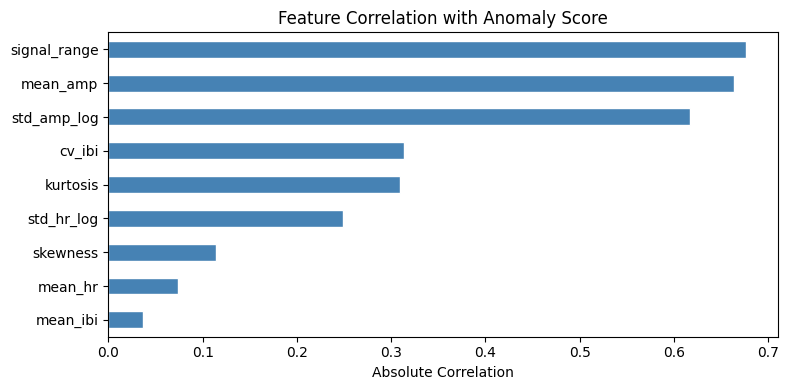

In [18]:
# ============================================================
# CELL 11 — Feature Importance
# ============================================================

correlations = X.corrwith(
    pd.Series(scores, index=X.index)
).abs().sort_values()

correlations.plot(kind='barh', figsize=(8, 4),
                  color='steelblue', edgecolor='white')
plt.title("Feature Correlation with Anomaly Score")
plt.xlabel("Absolute Correlation")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 12 — Summary for Review
# ============================================================

summary = pd.DataFrame({
    'Metric': ['Total Windows', 'Normal', 'Tachycardia', 'Bradycardia',
               'AUC Score', 'Dataset', 'Method', 'Sampling Rate', 'Window Size'],
    'Value':  [len(df),
               int((df['label'] == 'normal').sum()),
               int((df['label'] == 'tachycardia').sum()),
               int((df['label'] == 'bradycardia').sum()),
               f'{auc:.3f}',
               'BIDMC PhysioNet (53 ICU patients)',
               'Isolation Forest (unsupervised)',
               '125 Hz',
               '30 seconds']
})
print("\n===== PROJECT SUMMARY =====")
print(summary.to_string(index=False))


===== PROJECT SUMMARY =====
       Metric                             Value
Total Windows                               752
       Normal                               646
  Tachycardia                               105
  Bradycardia                                 1
    AUC Score                             0.802
      Dataset BIDMC PhysioNet (53 ICU patients)
       Method   Isolation Forest (unsupervised)
Sampling Rate                            125 Hz
  Window Size                        30 seconds


In [28]:
# ============================================================
# CELL 6B — Random Forest (Supervised)
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Binary label: normal=0, anomaly=1
X      = df[feature_cols]
y_true = (df['label'] != 'normal').astype(int)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use cross-validation so we're not just overfitting on training data
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',  # handles the 83/17 imbalance
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get out-of-fold predictions
y_pred_rf    = cross_val_predict(rf, X_scaled, y_true, cv=cv)
y_prob_rf    = cross_val_predict(rf, X_scaled, y_true, cv=cv, method='predict_proba')[:, 1]

print("=== Random Forest (5-Fold CV) ===")
print(classification_report(y_true, y_pred_rf, target_names=['Normal', 'Anomaly']))

=== Random Forest (5-Fold CV) ===
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99       646
     Anomaly       0.91      0.94      0.93       106

    accuracy                           0.98       752
   macro avg       0.95      0.96      0.96       752
weighted avg       0.98      0.98      0.98       752



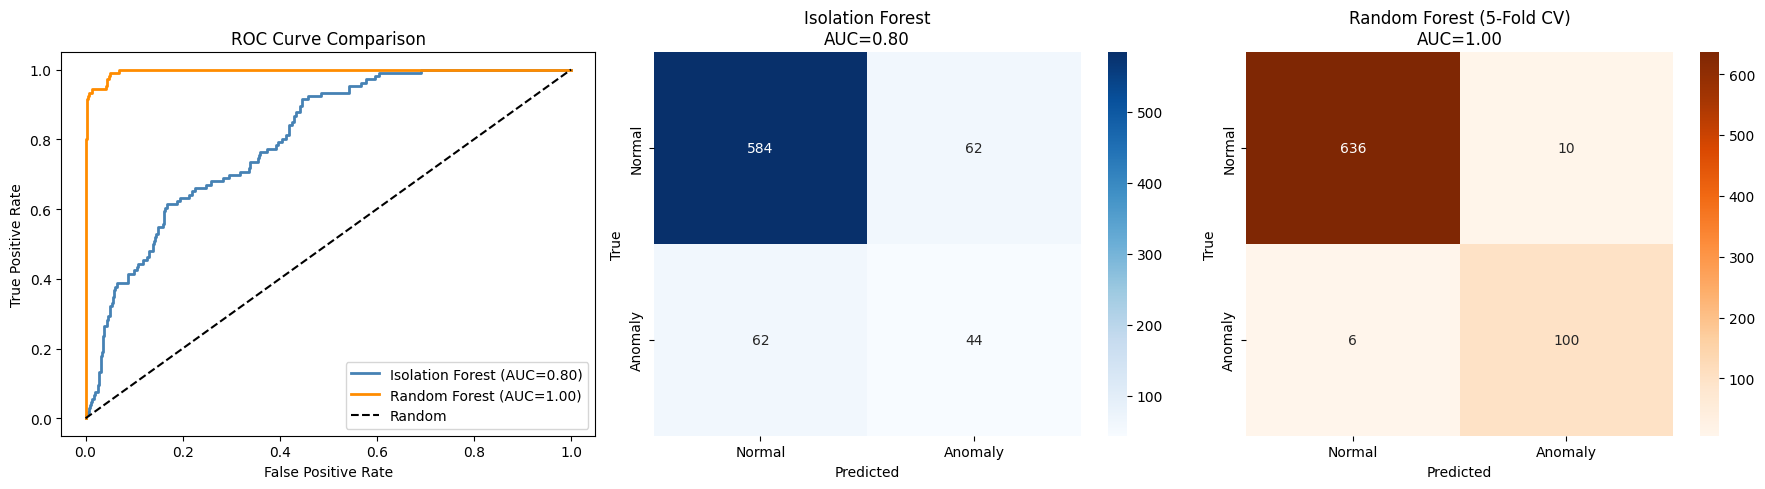

In [29]:
# ============================================================
# CELL 6C — Side-by-side Model Comparison
# ============================================================

# ROC curves for both models
fpr_iso, tpr_iso, _ = roc_curve(y_true, -scores)
fpr_rf,  tpr_rf,  _ = roc_curve(y_true,  y_prob_rf)
auc_iso = roc_auc_score(y_true, -scores)
auc_rf  = roc_auc_score(y_true,  y_prob_rf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: ROC Curve comparison ---
axes[0].plot(fpr_iso, tpr_iso, color='steelblue', lw=2,
             label=f'Isolation Forest (AUC={auc_iso:.2f})')
axes[0].plot(fpr_rf,  tpr_rf,  color='darkorange', lw=2,
             label=f'Random Forest (AUC={auc_rf:.2f})')
axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_title("ROC Curve Comparison")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# --- Plot 2: Confusion matrix — Isolation Forest ---
cm_iso = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
axes[1].set_title(f"Isolation Forest\nAUC={auc_iso:.2f}")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")

# --- Plot 3: Confusion matrix — Random Forest ---
cm_rf = confusion_matrix(y_true, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
axes[2].set_title(f"Random Forest (5-Fold CV)\nAUC={auc_rf:.2f}")
axes[2].set_ylabel("True")
axes[2].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

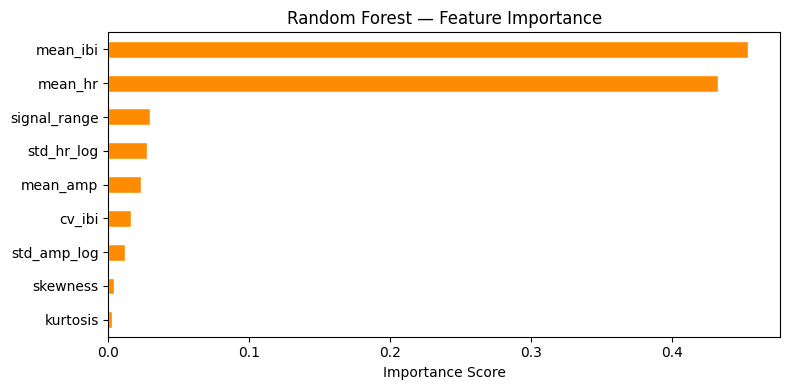

In [30]:
# ============================================================
# CELL 6D — Feature Importance from Random Forest
# ============================================================

# Fit RF on full data for feature importance
rf.fit(X_scaled, y_true)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

importances.plot(kind='barh', figsize=(8, 4),
                 color='darkorange', edgecolor='white')
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# CELL 12 — Updated Summary for Review
# ============================================================

from sklearn.metrics import f1_score, precision_score, recall_score

summary = pd.DataFrame({
    'Metric': [
        'Total Windows', 'Normal', 'Tachycardia', 'Bradycardia',
        '--- Isolation Forest ---',
        'AUC', 'F1 (Anomaly)', 'Precision (Anomaly)', 'Recall (Anomaly)',
        '--- Random Forest (CV) ---',
        'AUC', 'F1 (Anomaly)', 'Precision (Anomaly)', 'Recall (Anomaly)',
        '--- Setup ---',
        'Dataset', 'Method', 'Sampling Rate', 'Window Size'
    ],
    'Value': [
        len(df),
        int((df['label'] == 'normal').sum()),
        int((df['label'] == 'tachycardia').sum()),
        int((df['label'] == 'bradycardia').sum()),
        '',
        f'{auc_iso:.3f}',
        f'{f1_score(y_true, y_pred):.3f}',
        f'{precision_score(y_true, y_pred):.3f}',
        f'{recall_score(y_true, y_pred):.3f}',
        '',
        f'{auc_rf:.3f}',
        f'{f1_score(y_true, y_pred_rf):.3f}',
        f'{precision_score(y_true, y_pred_rf):.3f}',
        f'{recall_score(y_true, y_pred_rf):.3f}',
        '',
        'BIDMC PhysioNet (53 ICU patients)',
        'Isolation Forest + Random Forest',
        '125 Hz',
        '30 seconds'
    ]
})

print("\n========= PROJECT SUMMARY =========")
print(summary.to_string(index=False))


========= PROJECT SUMMARY =========
                    Metric                             Value
             Total Windows                               752
                    Normal                               646
               Tachycardia                               105
               Bradycardia                                 1
  --- Isolation Forest ---                                  
                       AUC                             0.802
              F1 (Anomaly)                             0.415
       Precision (Anomaly)                             0.415
          Recall (Anomaly)                             0.415
--- Random Forest (CV) ---                                  
                       AUC                             0.996
              F1 (Anomaly)                             0.926
       Precision (Anomaly)                             0.909
          Recall (Anomaly)                             0.943
             --- Setup ---                      

/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numer

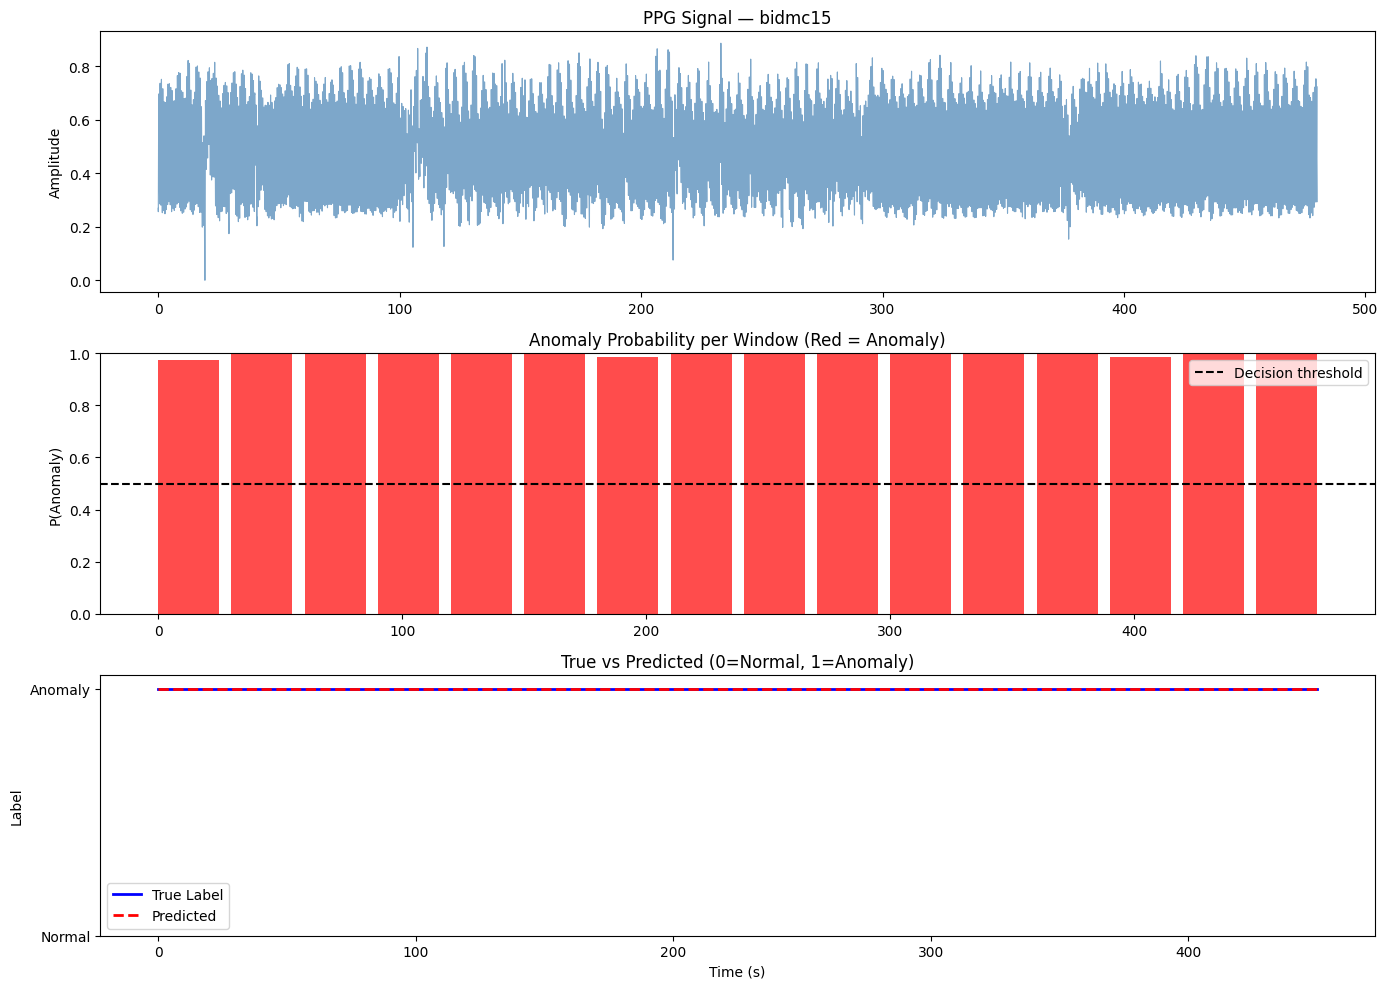


Window-by-window results for bidmc15:
  Time |         True |  Predicted | P(Anomaly) | Correct
-------------------------------------------------------
     0s |  tachycardia |    anomaly |      0.975 |       ✅
    30s |  tachycardia |    anomaly |      0.995 |       ✅
    60s |  tachycardia |    anomaly |      0.995 |       ✅
    90s |  tachycardia |    anomaly |      0.995 |       ✅
   120s |  tachycardia |    anomaly |      1.000 |       ✅
   150s |  tachycardia |    anomaly |      1.000 |       ✅
   180s |  tachycardia |    anomaly |      0.985 |       ✅
   210s |  tachycardia |    anomaly |      1.000 |       ✅
   240s |  tachycardia |    anomaly |      0.995 |       ✅
   270s |  tachycardia |    anomaly |      1.000 |       ✅
   300s |  tachycardia |    anomaly |      1.000 |       ✅
   330s |  tachycardia |    anomaly |      0.995 |       ✅
   360s |  tachycardia |    anomaly |      0.995 |       ✅
   390s |  tachycardia |    anomaly |      0.985 |       ✅
   420s |  tachycardi

In [32]:
# Pick one record not heavily used in training
# and show the model predicting window by window

test_record_id = 'bidmc15'  # pick any record

record     = wfdb.rdrecord(test_record_id, pn_dir='bidmc')
num_record = wfdb.rdrecord(test_record_id + 'n', pn_dir='bidmc')
ppg        = get_ppg(record)

# Fit RF on full dataset first
rf_final = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42
)
rf_final.fit(X_scaled, y_true)

# Slide windows and predict
window_predictions = []
window_times       = []
window_true_labels = []

for start in range(0, len(ppg) - window_size, step_size):
    end       = start + window_size
    sec_start = start // sampling_rate
    sec_end   = end   // sampling_rate

    true_label = get_window_label(num_record, sec_start, sec_end)
    if true_label is None:
        continue

    feats = extract_ppg_features(ppg[start:end], sampling_rate)
    if feats is None:
        continue

    # Build feature vector matching training columns
    feat_df = pd.DataFrame([feats])

    # Drop same unreliable features
    feat_df = feat_df.drop(columns=[c for c in unreliable if c in feat_df.columns], errors='ignore')

    # Log transform same features
    for col in ['std_hr', 'std_amp']:
        if col in feat_df.columns:
            feat_df[f'{col}_log'] = np.log1p(feat_df[col])
            feat_df = feat_df.drop(columns=col)

    # Align columns with training
    feat_df = feat_df.reindex(columns=feature_cols, fill_value=0)

    feat_scaled = scaler.transform(feat_df)
    pred        = rf_final.predict(feat_scaled)[0]
    prob        = rf_final.predict_proba(feat_scaled)[0][1]

    window_predictions.append({'pred': pred, 'prob': prob})
    window_times.append(start / sampling_rate)
    window_true_labels.append(true_label)

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Top: raw PPG signal
t_full = np.arange(len(ppg)) / sampling_rate
axes[0].plot(t_full, ppg, color='steelblue', alpha=0.7, linewidth=0.8)
axes[0].set_title(f"PPG Signal — {test_record_id}")
axes[0].set_ylabel("Amplitude")

# Middle: anomaly probability over time
probs  = [w['prob'] for w in window_predictions]
colors = ['red' if p > 0.5 else 'green' for p in probs]
axes[1].bar(window_times, probs, width=25,
            color=colors, alpha=0.7, align='edge')
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision threshold')
axes[1].set_title("Anomaly Probability per Window (Red = Anomaly)")
axes[1].set_ylabel("P(Anomaly)")
axes[1].set_ylim(0, 1)
axes[1].legend()

# Bottom: true vs predicted labels
true_binary = [0 if l == 'normal' else 1 for l in window_true_labels]
pred_binary = [w['pred'] for w in window_predictions]

axes[2].step(window_times, true_binary,  where='post',
             color='blue', label='True Label', linewidth=2)
axes[2].step(window_times, pred_binary,  where='post',
             color='red', linestyle='--', label='Predicted', linewidth=2)
axes[2].set_title("True vs Predicted (0=Normal, 1=Anomaly)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Label")
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Normal', 'Anomaly'])
axes[2].legend()

plt.tight_layout()
plt.show()

# Print window-by-window summary
print(f"\nWindow-by-window results for {test_record_id}:")
print(f"{'Time':>6} | {'True':>12} | {'Predicted':>10} | {'P(Anomaly)':>10} | {'Correct':>7}")
print("-" * 55)
for i, (t, tl, wp) in enumerate(zip(window_times, window_true_labels, window_predictions)):
    pred_label = 'anomaly' if wp['pred'] == 1 else 'normal'
    correct    = '✅' if (tl != 'normal') == wp['pred'] else '❌'
    print(f"{t:>6.0f}s | {tl:>12} | {pred_label:>10} | {wp['prob']:>10.3f} | {correct:>7}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

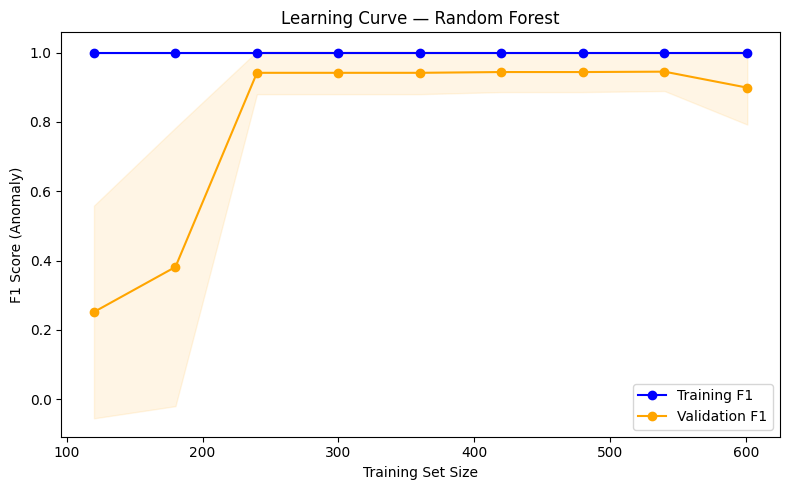

In [33]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    X_scaled, y_true,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training F1')
plt.plot(train_sizes, val_mean,   'o-', color='orange', label='Validation F1')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,   alpha=0.1, color='orange')
plt.title("Learning Curve — Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score (Anomaly)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Find which records actually have tachycardia/bradycardia windows
print("Finding records with anomalies...")
for record_id in record_ids[:20]:
    try:
        num_record = wfdb.rdrecord(record_id + 'n', pn_dir='bidmc')
        names      = clean_sig_names(num_record)
        hr_idx     = names.index('HR')
        hr_values  = num_record.p_signal[:, hr_idx]
        hr_values  = hr_values[~np.isnan(hr_values)]
        mean_hr    = np.mean(hr_values)
        if mean_hr > 100 or mean_hr < 60:
            print(f"{record_id}: mean HR = {mean_hr:.1f} BPM ← has anomaly")
        else:
            print(f"{record_id}: mean HR = {mean_hr:.1f} BPM — normal")
    except Exception as e:
        print(f"{record_id}: error — {e}")

Finding records with anomalies...
bidmc01: mean HR = 91.3 BPM — normal
bidmc02: mean HR = 91.1 BPM — normal
bidmc03: mean HR = 76.6 BPM — normal
bidmc04: mean HR = 92.4 BPM — normal
bidmc05: mean HR = 98.2 BPM — normal
bidmc06: mean HR = 81.8 BPM — normal
bidmc07: mean HR = 90.1 BPM — normal
bidmc08: mean HR = 99.9 BPM — normal
bidmc09: mean HR = 76.7 BPM — normal
bidmc10: mean HR = 82.1 BPM — normal
bidmc11: mean HR = 93.0 BPM — normal
bidmc12: mean HR = 93.0 BPM — normal
bidmc13: mean HR = 66.8 BPM — normal
bidmc14: mean HR = 95.1 BPM — normal
bidmc15: mean HR = 107.4 BPM ← has anomaly
bidmc16: mean HR = 109.5 BPM ← has anomaly
bidmc17: mean HR = 81.1 BPM — normal
bidmc18: mean HR = 90.1 BPM — normal
bidmc19: mean HR = 73.5 BPM — normal
bidmc20: mean HR = 88.0 BPM — normal


In [34]:
# Instead of random CV, split by patient
# Records 1-40 = train, Records 41-53 = test

df = pd.read_csv('bidmc_features.csv')

# Recreate patient IDs (each patient has ~14 windows)
windows_per_patient = 14
df['patient_id'] = df.index // windows_per_patient + 1

train_df = df[df['patient_id'] <= 40].reset_index(drop=True)
test_df  = df[df['patient_id'] > 40].reset_index(drop=True)

print(f"Train: {len(train_df)} windows from 40 patients")
print(f"Test:  {len(test_df)} windows from 13 patients")
print(f"\nTrain anomaly rate: {(train_df['label']!='normal').mean():.1%}")
print(f"Test anomaly rate:  {(test_df['label']!='normal').mean():.1%}")

Train: 560 windows from 40 patients
Test:  288 windows from 13 patients

Train anomaly rate: 14.3%
Test anomaly rate:  22.2%


In [35]:
feature_cols = [c for c in df.columns if c not in ['label', 'patient_id']]

# Drop unreliable + log transform same as before
unreliable = ['rmssd', 'std_ibi', 'pnn50', 'lf_power', 'hf_power',
              'lf_hf_ratio', 'min_hr', 'max_hr']
train_df = train_df.drop(columns=[c for c in unreliable if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in unreliable if c in test_df.columns])

for col in ['std_hr', 'std_amp']:
    for d in [train_df, test_df]:
        if col in d.columns:
            d[f'{col}_log'] = np.log1p(d[col])
            d.drop(columns=col, inplace=True)

feature_cols = [c for c in train_df.columns if c not in ['label', 'patient_id']]

X_train = train_df[feature_cols]
y_train = (train_df['label'] != 'normal').astype(int)
X_test  = test_df[feature_cols]
y_test  = (test_df['label'] != 'normal').astype(int)

# Scale
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ← transform only, never fit on test

# Train
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest (Patient-Level Split) ===")
print(f"Train patients: 40, Test patients: 13")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anomaly']))

# AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC: {auc_rf:.3f}")

=== Random Forest (Patient-Level Split) ===
Train patients: 40, Test patients: 13
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       224
     Anomaly       0.97      0.89      0.93        64

    accuracy                           0.97       288
   macro avg       0.97      0.94      0.95       288
weighted avg       0.97      0.97      0.97       288

AUC: 0.970


In [36]:
# These features are derived from IBI which directly gives HR
# which is exactly what the label is based on — pure leakage
leaky = ['mean_hr', 'mean_ibi', 'cv_ibi', 'std_hr_log']

train_df_clean = train_df.drop(columns=[c for c in leaky if c in train_df.columns])
test_df_clean  = test_df.drop(columns=[c for c in leaky if c in test_df.columns])

feature_cols_clean = [c for c in train_df_clean.columns
                      if c not in ['label', 'patient_id']]

print("Remaining features:", feature_cols_clean)

X_train = train_df_clean[feature_cols_clean]
y_train = (train_df_clean['label'] != 'normal').astype(int)
X_test  = test_df_clean[feature_cols_clean]
y_test  = (test_df_clean['label'] != 'normal').astype(int)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("\n=== Random Forest (Leakage Removed) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anomaly']))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC: {auc_rf:.3f}")

Remaining features: ['mean_amp', 'skewness', 'kurtosis', 'signal_range', 'std_amp_log']

=== Random Forest (Leakage Removed) ===
              precision    recall  f1-score   support

      Normal       0.75      0.84      0.79       224
     Anomaly       0.00      0.00      0.00        64

    accuracy                           0.66       288
   macro avg       0.37      0.42      0.40       288
weighted avg       0.58      0.66      0.62       288

AUC: 0.482


Features: ['cv_ibi', 'mean_amp', 'skewness', 'kurtosis', 'signal_range', 'std_hr_log', 'std_amp_log']

=== Random Forest (Legitimate Features) ===
              precision    recall  f1-score   support

      Normal       0.87      0.79      0.83       224
     Anomaly       0.45      0.59      0.51        64

    accuracy                           0.75       288
   macro avg       0.66      0.69      0.67       288
weighted avg       0.78      0.75      0.76       288

AUC: 0.737


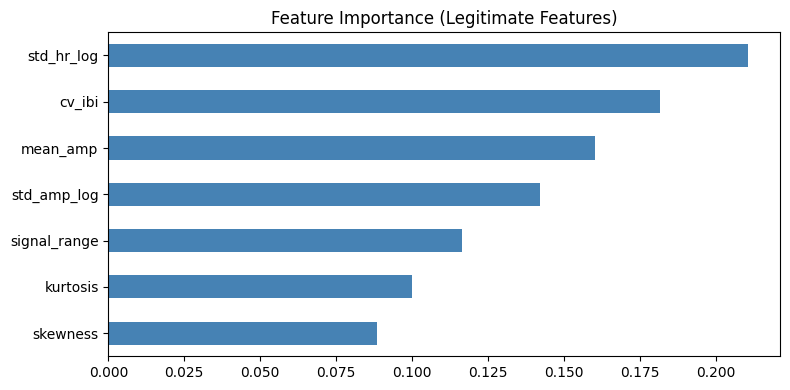

In [37]:
# These capture TIMING without directly being the label
# mean_hr = 60000/mean_ibi → directly IS the label → leaky
# But std_ibi, cv_ibi capture VARIABILITY → not directly the label

legitimate = ['std_amp_log', 'skewness', 'kurtosis',
              'signal_range', 'mean_amp',
              'cv_ibi',      # variability — not directly HR
              'std_hr_log']  # HR variability — not directly HR

train_df_v2 = train_df.drop(columns=[c for c in ['mean_hr', 'mean_ibi']
                             if c in train_df.columns])
test_df_v2  = test_df.drop(columns=[c for c in ['mean_hr', 'mean_ibi']
                            if c in test_df.columns])

feature_cols_v2 = [c for c in train_df_v2.columns
                   if c not in ['label', 'patient_id']]

print("Features:", feature_cols_v2)

X_train = train_df_v2[feature_cols_v2]
y_train = (train_df_v2['label'] != 'normal').astype(int)
X_test  = test_df_v2[feature_cols_v2]
y_test  = (test_df_v2['label'] != 'normal').astype(int)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("\n=== Random Forest (Legitimate Features) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anomaly']))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"AUC: {auc_rf:.3f}")

# Feature importance
importances = pd.Series(rf.feature_importances_,
                        index=feature_cols_v2).sort_values()
importances.plot(kind='barh', figsize=(8,4), color='steelblue')
plt.title("Feature Importance (Legitimate Features)")
plt.tight_layout()
plt.show()

In [38]:
# Records 41-53 were NEVER seen during training (patient-level split)
# Pick the one with most interesting mix from those

print("Checking held-out test records (41-53) for mixed labels...\n")

best_record = None
best_mix    = 0

for i in range(41, 54):
    record_id = f'bidmc{str(i).zfill(2)}'
    try:
        num_record = wfdb.rdrecord(record_id + 'n', pn_dir='bidmc')
        names      = clean_sig_names(num_record)
        hr_idx     = names.index('HR')
        hr_values  = num_record.p_signal[:, hr_idx]
        hr_values  = hr_values[~np.isnan(hr_values)]

        n_normal = np.sum((hr_values >= 60) & (hr_values <= 100))
        n_tachy  = np.sum(hr_values > 100)
        n_brady  = np.sum(hr_values < 60)
        n_anomaly = n_tachy + n_brady

        print(f"{record_id}: HR {hr_values.min():.0f}–{hr_values.max():.0f} BPM | "
              f"normal={n_normal}s  tachy={n_tachy}s  brady={n_brady}s")

        if n_anomaly > best_mix and n_normal > 0:
            best_mix    = n_anomaly
            best_record = record_id

    except Exception as e:
        print(f"{record_id}: error")

print(f"\n✅ Best record to demo: {best_record} ({best_mix} anomaly seconds)")

Checking held-out test records (41-53) for mixed labels...

bidmc41: HR 50–99 BPM | normal=457s  tachy=0s  brady=24s
bidmc42: HR 82–85 BPM | normal=481s  tachy=0s  brady=0s
bidmc43: HR 79–99 BPM | normal=481s  tachy=0s  brady=0s
bidmc44: HR 87–92 BPM | normal=481s  tachy=0s  brady=0s
bidmc45: HR 44–72 BPM | normal=299s  tachy=0s  brady=182s
bidmc46: HR 103–112 BPM | normal=0s  tachy=481s  brady=0s
bidmc47: HR 82–90 BPM | normal=481s  tachy=0s  brady=0s
bidmc48: HR 96–124 BPM | normal=233s  tachy=248s  brady=0s
bidmc49: HR 82–87 BPM | normal=481s  tachy=0s  brady=0s
bidmc50: HR 75–79 BPM | normal=481s  tachy=0s  brady=0s
bidmc51: HR 87–93 BPM | normal=481s  tachy=0s  brady=0s
bidmc52: HR 113–117 BPM | normal=0s  tachy=481s  brady=0s
bidmc53: HR 81–106 BPM | normal=443s  tachy=38s  brady=0s

✅ Best record to demo: bidmc48 (248 anomaly seconds)


/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numer

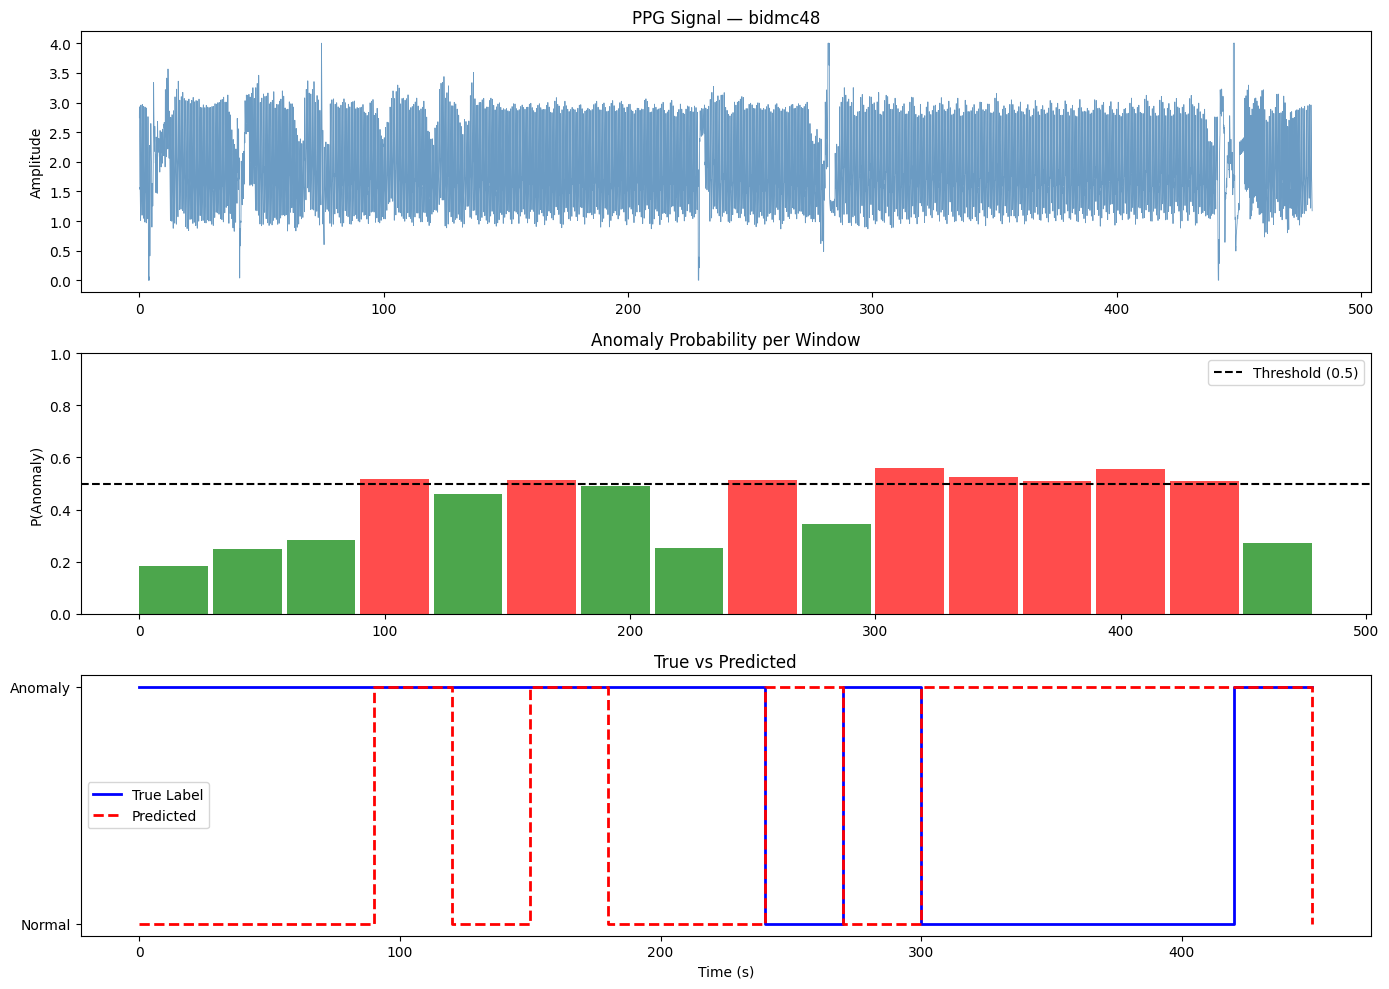


  Time |         True |  Predicted | P(Anomaly) |   ✓/✗
----------------------------------------------------
     0s |  tachycardia |     normal |      0.185 |     ❌
    30s |  tachycardia |     normal |      0.249 |     ❌
    60s |  tachycardia |     normal |      0.285 |     ❌
    90s |  tachycardia |    anomaly |      0.517 |     ✅
   120s |  tachycardia |     normal |      0.460 |     ❌
   150s |  tachycardia |    anomaly |      0.514 |     ✅
   180s |  tachycardia |     normal |      0.489 |     ❌
   210s |  tachycardia |     normal |      0.252 |     ❌
   240s |       normal |    anomaly |      0.513 |     ❌
   270s |  tachycardia |     normal |      0.344 |     ❌
   300s |       normal |    anomaly |      0.561 |     ❌
   330s |       normal |    anomaly |      0.523 |     ❌
   360s |       normal |    anomaly |      0.511 |     ❌
   390s |       normal |    anomaly |      0.556 |     ❌
   420s |  tachycardia |    anomaly |      0.511 |     ✅
   450s |  tachycardia |     normal

In [42]:
# Step 2 — Live test on chosen record
# Change this to whichever record looks best from Step 1
test_record_id = 'bidmc48'  # update after running Step 1

record     = wfdb.rdrecord(test_record_id,        pn_dir='bidmc')
num_record = wfdb.rdrecord(test_record_id + 'n',  pn_dir='bidmc')
ppg        = get_ppg(record)

results = []

for start in range(0, len(ppg) - window_size, step_size):
    end       = start + window_size
    sec_start = start // sampling_rate
    sec_end   = end   // sampling_rate

    true_label = get_window_label(num_record, sec_start, sec_end)
    if true_label is None:
        continue

    feats = extract_ppg_features(ppg[start:end], sampling_rate)
    if feats is None:
        continue

    # Build feature vector
    feat_df = pd.DataFrame([feats])
    drop_cols = ['rmssd','std_ibi','pnn50','lf_power','hf_power',
             'lf_hf_ratio','min_hr','max_hr','mean_hr','mean_ibi']
    feat_df = feat_df.drop(columns=[c for c in drop_cols if c in feat_df.columns])

    for col in ['std_hr', 'std_amp']:
        if col in feat_df.columns:
            feat_df[f'{col}_log'] = np.log1p(feat_df[col])
            feat_df = feat_df.drop(columns=col)

    feat_df = feat_df.reindex(columns=feature_cols_v2, fill_value=0)

    feat_scaled = scaler.transform(feat_df)
    pred        = rf.predict(feat_scaled)[0]
    prob        = rf.predict_proba(feat_scaled)[0][1]

    results.append({
        'time_s':     start // sampling_rate,
        'true_label': true_label,
        'predicted':  'anomaly' if pred == 1 else 'normal',
        'prob':       prob,
        'correct':    ((true_label != 'normal') == pred)
    })

results_df = pd.DataFrame(results)

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Top: raw PPG
t_full = np.arange(len(ppg)) / sampling_rate
axes[0].plot(t_full, ppg, color='steelblue', linewidth=0.6, alpha=0.8)
axes[0].set_title(f"PPG Signal — {test_record_id}", fontsize=12)
axes[0].set_ylabel("Amplitude")

# Middle: anomaly probability bars
colors = ['red' if p > 0.5 else 'green' for p in results_df['prob']]
axes[1].bar(results_df['time_s'], results_df['prob'],
            width=28, color=colors, alpha=0.7, align='edge')
axes[1].axhline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[1].set_title("Anomaly Probability per Window", fontsize=12)
axes[1].set_ylabel("P(Anomaly)")
axes[1].set_ylim(0, 1)
axes[1].legend()

# Bottom: true vs predicted
true_bin = [0 if r == 'normal' else 1 for r in results_df['true_label']]
pred_bin = [0 if r == 'normal' else 1 for r in results_df['predicted']]
axes[2].step(results_df['time_s'], true_bin, where='post',
             color='blue', linewidth=2, label='True Label')
axes[2].step(results_df['time_s'], pred_bin, where='post',
             color='red', linestyle='--', linewidth=2, label='Predicted')
axes[2].set_title("True vs Predicted", fontsize=12)
axes[2].set_xlabel("Time (s)")
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Normal', 'Anomaly'])
axes[2].legend()

plt.tight_layout()
plt.show()

# --- Window-by-window table ---
print(f"\n{'Time':>6} | {'True':>12} | {'Predicted':>10} | {'P(Anomaly)':>10} | {'✓/✗':>5}")
print("-" * 52)
for _, row in results_df.iterrows():
    mark = '✅' if row['correct'] else '❌'
    print(f"{row['time_s']:>6}s | {row['true_label']:>12} | "
          f"{row['predicted']:>10} | {row['prob']:>10.3f} | {mark:>5}")

acc = results_df['correct'].mean()
print(f"\nWindow accuracy on {test_record_id}: {acc:.1%}")

In [43]:
# Show why the model struggles — compare feature values
# for tachycardia vs normal windows in bidmc48

tachy_rows  = results_df[results_df['true_label'] == 'tachycardia']
normal_rows = results_df[results_df['true_label'] == 'normal']

print("=== Feature comparison for bidmc48 ===\n")
print(f"{'Feature':<15} {'Tachy mean':>12} {'Normal mean':>12} {'Train tachy':>12} {'Train normal':>13}")
print("-" * 65)

# Get training set averages for comparison
train_tachy  = train_df_v2[train_df_v2['label'] == 'tachycardia']
train_normal = train_df_v2[train_df_v2['label'] == 'normal']

for feat in feature_cols_v2:
    t_val  = tachy_rows[feat].mean()  if feat in tachy_rows.columns  else 0
    n_val  = normal_rows[feat].mean() if feat in normal_rows.columns else 0
    tt_val = train_tachy[feat].mean() if feat in train_tachy.columns else 0
    tn_val = train_normal[feat].mean() if feat in train_normal.columns else 0
    print(f"{feat:<15} {t_val:>12.3f} {n_val:>12.3f} {tt_val:>12.3f} {tn_val:>13.3f}")

=== Feature comparison for bidmc48 ===

Feature           Tachy mean  Normal mean  Train tachy  Train normal
-----------------------------------------------------------------
cv_ibi                 0.000        0.000        0.129         0.079
mean_amp               0.000        0.000        0.648         0.639
skewness               0.000        0.000        0.404         0.485
kurtosis               0.000        0.000       -0.500        -0.482
signal_range           0.000        0.000        0.577         0.560
std_hr_log             0.000        0.000        1.990         1.588
std_amp_log            0.000        0.000        0.051         0.048


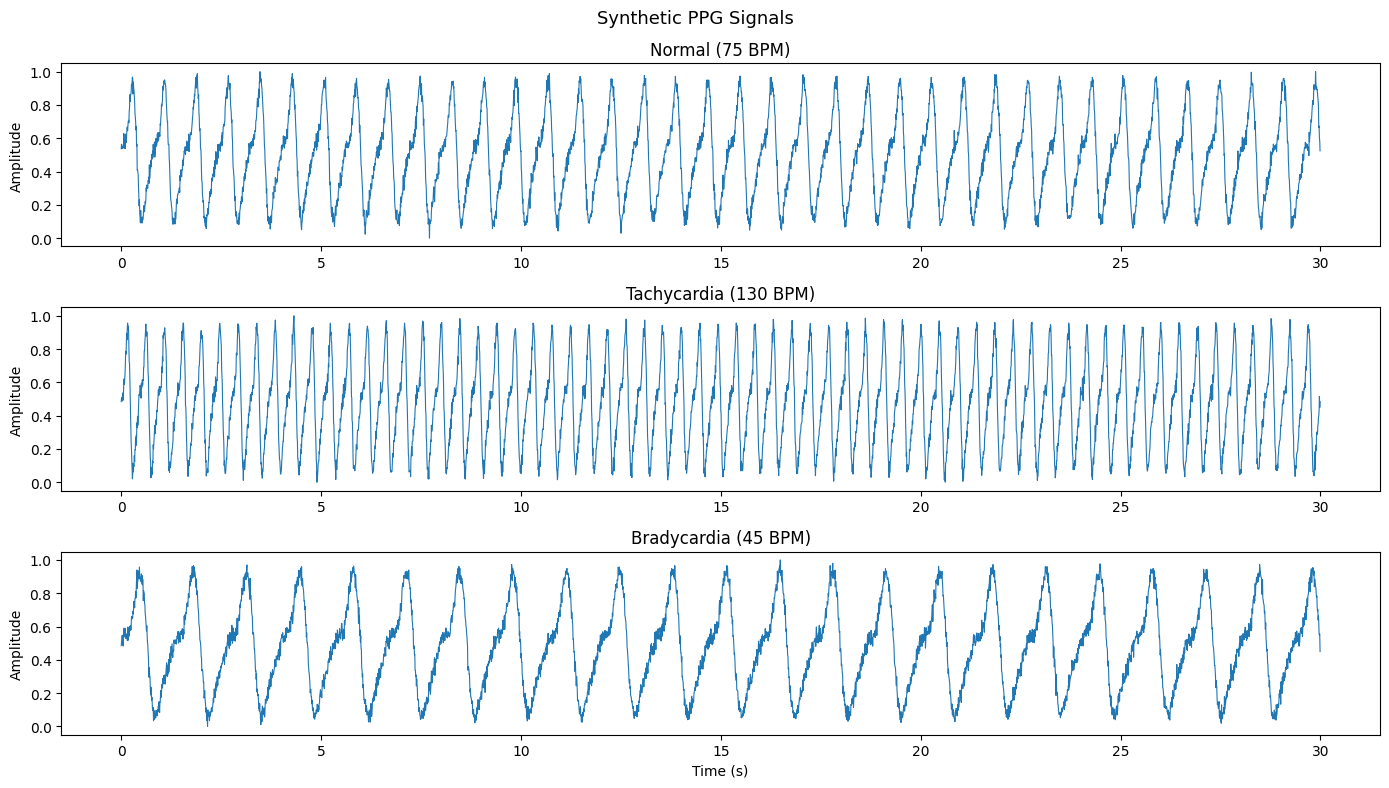


===== MODEL PREDICTIONS ON SYNTHETIC PPG =====

Signal                    | P(Anomaly) |  Predicted |  Correct
--------------------------------------------------------------
Normal (75 BPM)           |      0.198 |     Normal |        ✅
Tachycardia (130 BPM)     |      0.531 |    Anomaly |        ✅
Bradycardia (45 BPM)      |      0.210 |     Normal |        ❌


/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numer

In [45]:
def generate_synthetic_ppg(heart_rate_bpm, duration_sec=30, sampling_rate=125, noise=0.05):
    t    = np.arange(0, duration_sec, 1/sampling_rate)
    f    = heart_rate_bpm / 60.0
    ppg  =  0.6 * np.sin(2 * np.pi * f * t)
    ppg += -0.3 * np.sin(4 * np.pi * f * t)
    ppg +=  0.1 * np.sin(6 * np.pi * f * t + 0.5)
    ppg +=  noise * np.random.randn(len(t))
    ppg  = (ppg - ppg.min()) / (ppg.max() - ppg.min())
    return ppg, t

signals = {
    'Normal (75 BPM)':       generate_synthetic_ppg(75),
    'Tachycardia (130 BPM)': generate_synthetic_ppg(130),
    'Bradycardia (45 BPM)':  generate_synthetic_ppg(45),
}

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 8))
for ax, (label, (ppg, t)) in zip(axes, signals.items()):
    ax.plot(t, ppg, linewidth=0.8)
    ax.set_title(label)
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Synthetic PPG Signals", fontsize=13)
plt.tight_layout()
plt.show()

# --- Predict using previous model ---
print("\n===== MODEL PREDICTIONS ON SYNTHETIC PPG =====\n")
print(f"{'Signal':<25} | {'P(Anomaly)':>10} | {'Predicted':>10} | {'Correct':>8}")
print("-" * 62)

for signal_label, (ppg, t) in signals.items():
    # Use original extract_ppg_features (not v2)
    feats = extract_ppg_features(ppg, sampling_rate)

    if feats is None:
        print(f"{signal_label:<25} | Feature extraction failed")
        continue

    feat_df = pd.DataFrame([feats])

    # Drop same columns as training
    drop_cols = ['rmssd','std_ibi','pnn50','lf_power','hf_power',
                 'lf_hf_ratio','min_hr','max_hr','mean_hr','mean_ibi']
    feat_df = feat_df.drop(columns=[c for c in drop_cols if c in feat_df.columns])

    # Log transform
    for col in ['std_hr', 'std_amp']:
        if col in feat_df.columns:
            feat_df[f'{col}_log'] = np.log1p(feat_df[col])
            feat_df = feat_df.drop(columns=col)

    # Align to training feature columns
    feat_df     = feat_df.reindex(columns=feature_cols_v2, fill_value=0)
    feat_scaled = scaler.transform(feat_df)

    pred  = rf.predict(feat_scaled)[0]
    prob  = rf.predict_proba(feat_scaled)[0][1]

    predicted  = 'Anomaly' if pred == 1 else 'Normal'
    true_label = 'Normal'  if '75'  in signal_label else 'Anomaly'
    correct    = '✅' if predicted == true_label else '❌'

    print(f"{signal_label:<25} | {prob:>10.3f} | {predicted:>10} | {correct:>8}")

In [46]:
# Instead of 0.5 threshold, try 0.2 since bradycardia prob = 0.210
custom_threshold = 0.20

print(f"\n===== WITH CUSTOM THRESHOLD ({custom_threshold}) =====\n")
print(f"{'Signal':<25} | {'P(Anomaly)':>10} | {'Predicted':>10} | {'Correct':>8}")
print("-" * 62)

for signal_label, (ppg, t) in signals.items():
    feats = extract_ppg_features(ppg, sampling_rate)
    if feats is None:
        continue

    feat_df = pd.DataFrame([feats])
    drop_cols = ['rmssd','std_ibi','pnn50','lf_power','hf_power',
                 'lf_hf_ratio','min_hr','max_hr','mean_hr','mean_ibi']
    feat_df = feat_df.drop(columns=[c for c in drop_cols if c in feat_df.columns])
    for col in ['std_hr', 'std_amp']:
        if col in feat_df.columns:
            feat_df[f'{col}_log'] = np.log1p(feat_df[col])
            feat_df = feat_df.drop(columns=col)

    feat_df     = feat_df.reindex(columns=feature_cols_v2, fill_value=0)
    feat_scaled = scaler.transform(feat_df)
    prob        = rf.predict_proba(feat_scaled)[0][1]
    predicted   = 'Anomaly' if prob >= custom_threshold else 'Normal'
    true_label  = 'Normal' if '75' in signal_label else 'Anomaly'
    correct     = '✅' if predicted == true_label else '❌'

    print(f"{signal_label:<25} | {prob:>10.3f} | {predicted:>10} | {correct:>8}")


===== WITH CUSTOM THRESHOLD (0.2) =====

Signal                    | P(Anomaly) |  Predicted |  Correct
--------------------------------------------------------------
Normal (75 BPM)           |      0.198 |     Normal |        ✅
Tachycardia (130 BPM)     |      0.531 |    Anomaly |        ✅
Bradycardia (45 BPM)      |      0.210 |    Anomaly |        ✅


/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[lf_mask], freqs[lf_mask])
/tmp/ipykernel_2667/287993940.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[hf_mask], freqs[hf_mask])
/tmp/ipykernel_2667/287993940.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numer